<a href="https://colab.research.google.com/github/SathyaPrakashD/Made-With-ML/blob/main/MadeWithML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#import Data

In [ ]:
import pandas as pd

In [ ]:
# Data ingestion
DATASET_LOC = "https://raw.githubusercontent.com/GokuMohandas/Made-With-ML/main/datasets/dataset.csv"
df = pd.read_csv(DATASET_LOC)
df.head(20)

,id,created_on,title,description,tag
0,6,2020-02-20 06:43:18,Comparison between YOLO and RCNN on real world...,Bringing theory to experiment is cool. We can ...,computer-vision
1,7,2020-02-20 06:47:21,"Show, Infer & Tell: Contextual Inference for C...",The beauty of the work lies in the way it arch...,computer-vision
2,9,2020-02-24 16:24:45,Awesome Graph Classification,"A collection of important graph embedding, cla...",other
3,15,2020-02-28 23:55:26,Awesome Monte Carlo Tree Search,A curated list of Monte Carlo tree search pape...,other
4,25,2020-03-07 23:04:31,AttentionWalk,"A PyTorch Implementation of ""Watch Your Step: ...",other
5,27,2020-03-07 23:18:15,APPNP and PPNP,"A PyTorch implementation of ""Predict then Prop...",other
6,28,2020-03-07 23:23:46,Attributed Social Network Embedding,A sparsity aware and memory efficient implemen...,other
7,29,2020-03-07 23:45:38,Signed Graph Convolutional Network,"A PyTorch implementation of ""Signed Graph Conv...",other
8,45,2020-03-08 00:39:08,SimGNN,"A PyTorch implementation of ""SimGNN: A Neural ...",other
9,61,2020-03-16 17:35:22,Using JAX to Improve Separable Image Filters,Optimizing the filters to improve the filtered...,computer-vision


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Value counts
df.tag.value_counts()

,count
tag,
natural-language-processing,310
computer-vision,285
other,106
mlops,63


In [ ]:
# Split dataset
test_size = 0.2
train_df, val_df = train_test_split(df, stratify=df.tag, test_size=test_size, random_state=1234)

In [ ]:
# Train value counts
train_df.tag.value_counts()

,count
tag,
natural-language-processing,248
computer-vision,228
other,85
mlops,50


In [ ]:
# Validation value counts
val_df.tag.value_counts()

,count
tag,
natural-language-processing,62
computer-vision,57
other,21
mlops,13


In [ ]:
# Validation (adjusted) value counts
val_df.tag.value_counts() * int((1-test_size) / test_size)

,count
tag,
natural-language-processing,248
computer-vision,228
other,84
mlops,52


# EDA - Exploratory Data Analysis

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()
import warnings; warnings.filterwarnings("ignore")
from wordcloud import WordCloud, STOPWORDS

##How many data points do we have per tag? We'll use the Counter class to get counts for all the different tags.

In [ ]:
# Most common tags
all_tags = Counter(df.tag)
all_tags.most_common()

[('natural-language-processing', 310),
 ('computer-vision', 285),
 ('other', 106),
 ('mlops', 63)]

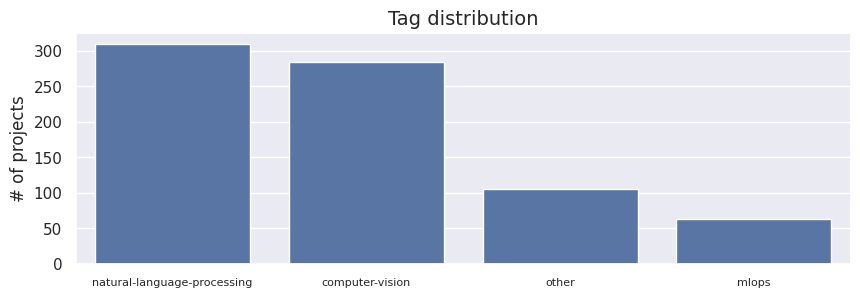

In [ ]:
# Plot tag frequencies
tags, tag_counts = zip(*all_tags.most_common())
plt.figure(figsize=(10, 3))
ax = sns.barplot(x=list(tags), y=list(tag_counts))
ax.set_xticklabels(tags, rotation=0, fontsize=8)
plt.title("Tag distribution", fontsize=14)
plt.ylabel("# of projects", fontsize=12)
plt.show()

##Is there enough signal in the title and description that's unique to each tag?

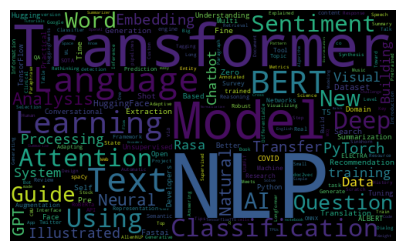

In [ ]:
# Most frequent tokens for each tag
tag="natural-language-processing"
plt.figure(figsize=(10, 3))
subset = df[df.tag==tag]
text = subset.title.values
cloud = WordCloud(
    stopwords=STOPWORDS, background_color="black", collocations=False,
    width=500, height=300).generate(" ".join(text))
plt.axis("off")
plt.imshow(cloud)

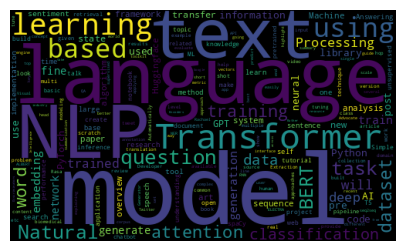

In [ ]:
# Most frequent tokens for each tag
tag="natural-language-processing"
plt.figure(figsize=(10, 3))
subset = df[df.tag==tag]
text = subset.description.values
cloud_2 = WordCloud(
    stopwords=STOPWORDS, background_color="black", collocations=False,
    width=500, height=300).generate(" ".join(text))
plt.axis("off")
plt.imshow(cloud_2)

In [ ]:
df.head()

,id,created_on,title,description,tag
0,6,2020-02-20 06:43:18,Comparison between YOLO and RCNN on real world...,Bringing theory to experiment is cool. We can ...,computer-vision
1,7,2020-02-20 06:47:21,"Show, Infer & Tell: Contextual Inference for C...",The beauty of the work lies in the way it arch...,computer-vision
2,9,2020-02-24 16:24:45,Awesome Graph Classification,"A collection of important graph embedding, cla...",other
3,15,2020-02-28 23:55:26,Awesome Monte Carlo Tree Search,A curated list of Monte Carlo tree search pape...,other
4,25,2020-03-07 23:04:31,AttentionWalk,"A PyTorch Implementation of ""Watch Your Step: ...",other


##Checking if any of title column rows are empty

In [ ]:
missing_title_rows = df[df['title'].isnull()]
print(f"Number of rows with missing 'title' values: {len(missing_title_rows)}")
display(missing_title_rows.head())

Number of rows with missing 'title' values: 0


,id,created_on,title,description,tag


In [ ]:
pd.set_option('display.max_colwidth', None)
display(df.head())
# You can reset the option to a default value if needed, for example:
# pd.set_option('display.max_colwidth', 50)

,id,created_on,title,description,tag
0,6,2020-02-20 06:43:18,Comparison between YOLO and RCNN on real world videos,Bringing theory to experiment is cool. We can easily train models in colab and find the results in minutes.,computer-vision
1,7,2020-02-20 06:47:21,"Show, Infer & Tell: Contextual Inference for Creative Captioning",The beauty of the work lies in the way it architects the fundamental idea that humans look at the overall image and then individual pieces of it.\n,computer-vision
2,9,2020-02-24 16:24:45,Awesome Graph Classification,"A collection of important graph embedding, classification and representation learning papers with implementations.",other
3,15,2020-02-28 23:55:26,Awesome Monte Carlo Tree Search,A curated list of Monte Carlo tree search papers with implementations.,other
4,25,2020-03-07 23:04:31,AttentionWalk,"A PyTorch Implementation of ""Watch Your Step: Learning Node Embeddings via Graph Attention"" (NeurIPS 2018).",other


## Checking if description columns are empty

In [ ]:
missing_description_rows = df[df['description'].isnull()]
print(f"Number of rows with missing 'description' values: {len(missing_description_rows)}")
display(missing_description_rows.head())

Number of rows with missing 'description' values: 0


,id,created_on,title,description,tag


## Checking if any of the Tag column rows are empty

In [ ]:
missing_tag_rows = df[df['tag'].isnull()]
print(f"Number of rows with missing 'tag' values: {len(missing_tag_rows)}")
display(missing_tag_rows.head())

Number of rows with missing 'tag' values: 0


,id,created_on,title,description,tag


##Feature engineering

###We can combine existing input features to create new meaningful signal for helping the model learn. However, there's usually no simple way to know if certain feature combinations will help or not without empirically experimenting with the different combinations. Here, we could use a project's title and description separately as features but we'll combine them to create one input feature

In [ ]:
import json
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

In [ ]:
# Input
df["text"] = df.title + " " + df.description

In [ ]:
df.head()

,id,created_on,title,description,tag,text
0,6,2020-02-20 06:43:18,Comparison between YOLO and RCNN on real world videos,Bringing theory to experiment is cool. We can easily train models in colab and find the results in minutes.,computer-vision,Comparison between YOLO and RCNN on real world videos Bringing theory to experiment is cool. We can easily train models in colab and find the results in minutes.
1,7,2020-02-20 06:47:21,"Show, Infer & Tell: Contextual Inference for Creative Captioning",The beauty of the work lies in the way it architects the fundamental idea that humans look at the overall image and then individual pieces of it.\n,computer-vision,"Show, Infer & Tell: Contextual Inference for Creative Captioning The beauty of the work lies in the way it architects the fundamental idea that humans look at the overall image and then individual pieces of it.\n"
2,9,2020-02-24 16:24:45,Awesome Graph Classification,"A collection of important graph embedding, classification and representation learning papers with implementations.",other,"Awesome Graph Classification A collection of important graph embedding, classification and representation learning papers with implementations."
3,15,2020-02-28 23:55:26,Awesome Monte Carlo Tree Search,A curated list of Monte Carlo tree search papers with implementations.,other,Awesome Monte Carlo Tree Search A curated list of Monte Carlo tree search papers with implementations.
4,25,2020-03-07 23:04:31,AttentionWalk,"A PyTorch Implementation of ""Watch Your Step: Learning Node Embeddings via Graph Attention"" (NeurIPS 2018).",other,"AttentionWalk A PyTorch Implementation of ""Watch Your Step: Learning Node Embeddings via Graph Attention"" (NeurIPS 2018)."


##Cleaning

###Since we're dealing with text data, we can apply some common text preprocessing operations. Here, we'll be using Python's built-in regular expressions library re and the Natural Language Toolkit nltk.

In [ ]:
nltk.download("stopwords")
STOPWORDS = stopwords.words("english")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
def clean_text(text, stopwords=STOPWORDS):
    """Clean raw text string."""
    # Lower
    text = text.lower()

    # Remove stopwords
    pattern = re.compile(r'\b(' + r"|".join(stopwords) + r")\b\s*")
    text = pattern.sub('', text)

    # Spacing and filters
    text = re.sub(r"([!\"'#$%&()*\+,-./:;<=>?@\\\[\]^_`{|}~])", r" \1 ", text)  # add spacing
    text = re.sub("[^A-Za-z0-9]+", " ", text)  # remove non alphanumeric chars
    text = re.sub(" +", " ", text)  # remove multiple spaces
    text = text.strip()  # strip white space at the ends
    text = re.sub(r"http\S+", "", text)  #  remove links

    return text

###Once we're defined our function, we can apply it to each row in our dataframe via pandas.DataFrame.apply.

In [ ]:
# Apply to dataframe
original_df = df.copy()
df.text = df.text.apply(clean_text)
print (f"{original_df.text.values[0]}\n{df.text.values[0]}")

Comparison between YOLO and RCNN on real world videos Bringing theory to experiment is cool. We can easily train models in colab and find the results in minutes.
comparison yolo rcnn real world videos bringing theory experiment cool easily train models colab find results minutes


In [ ]:
df.head()

,id,created_on,title,description,tag,text
0,6,2020-02-20 06:43:18,Comparison between YOLO and RCNN on real world videos,Bringing theory to experiment is cool. We can easily train models in colab and find the results in minutes.,computer-vision,comparison yolo rcnn real world videos bringing theory experiment cool easily train models colab find results minutes
1,7,2020-02-20 06:47:21,"Show, Infer & Tell: Contextual Inference for Creative Captioning",The beauty of the work lies in the way it architects the fundamental idea that humans look at the overall image and then individual pieces of it.\n,computer-vision,show infer tell contextual inference creative captioning beauty work lies way architects fundamental idea humans look overall image individual pieces
2,9,2020-02-24 16:24:45,Awesome Graph Classification,"A collection of important graph embedding, classification and representation learning papers with implementations.",other,awesome graph classification collection important graph embedding classification representation learning papers implementations
3,15,2020-02-28 23:55:26,Awesome Monte Carlo Tree Search,A curated list of Monte Carlo tree search papers with implementations.,other,awesome monte carlo tree search curated list monte carlo tree search papers implementations
4,25,2020-03-07 23:04:31,AttentionWalk,"A PyTorch Implementation of ""Watch Your Step: Learning Node Embeddings via Graph Attention"" (NeurIPS 2018).",other,attentionwalk pytorch implementation watch step learning node embeddings via graph attention neurips 2018


###We'll wrap up our cleaning operation by removing columns (pandas.DataFrame.drop) and rows with null tag values (pandas.DataFrame.dropna).

In [ ]:
# DataFrame cleanup
df = df.drop(columns=["id", "created_on", "title", "description"], errors="ignore")  # drop cols
df = df.dropna(subset=["tag"])  # drop nulls
df = df[["text", "tag"]]  # rearrange cols
df.head()

,text,tag
0,comparison yolo rcnn real world videos bringing theory experiment cool easily train models colab find results minutes,computer-vision
1,show infer tell contextual inference creative captioning beauty work lies way architects fundamental idea humans look overall image individual pieces,computer-vision
2,awesome graph classification collection important graph embedding classification representation learning papers implementations,other
3,awesome monte carlo tree search curated list monte carlo tree search papers implementations,other
4,attentionwalk pytorch implementation watch step learning node embeddings via graph attention neurips 2018,other


##Encoding

###We need to encode our data into numerical values so that our models can process them. We'll start by encoding our text labels into unique indices.

In [ ]:
# Label to index
tags = train_df.tag.unique().tolist()
num_classes = len(tags)
class_to_index = {tag: i for i, tag in enumerate(tags)}
class_to_index

{'mlops': 0,
 'natural-language-processing': 1,
 'computer-vision': 2,
 'other': 3}

###Next, we can use the pandas.Series.map function to map our class_to_index dictionary on our tag column to encode our labels.

In [ ]:
# Encode labels
df["tag"] = df["tag"].map(class_to_index)
df.head()

,text,tag
0,comparison yolo rcnn real world videos bringing theory experiment cool easily train models colab find results minutes,2
1,show infer tell contextual inference creative captioning beauty work lies way architects fundamental idea humans look overall image individual pieces,2
2,awesome graph classification collection important graph embedding classification representation learning papers implementations,3
3,awesome monte carlo tree search curated list monte carlo tree search papers implementations,3
4,attentionwalk pytorch implementation watch step learning node embeddings via graph attention neurips 2018,3


###We'll also want to be able to decode our predictions back into text labels. We can do this by creating an index_to_class dictionary and using that to convert encoded labels back into text labels.

In [ ]:
def decode(indices, index_to_class):
    return [index_to_class[index] for index in indices]


In [ ]:
index_to_class = {v:k for k, v in class_to_index.items()}
decode(df.head()["tag"].values, index_to_class=index_to_class)

['computer-vision', 'computer-vision', 'other', 'other', 'other']

##Tokenizer

###Next we'll encode our text as well. Instead of using a random dictionary, we'll use a tokenizer that was used for a pretrained LLM (scibert) to tokenize our text. We'll be fine-tuning this exact model later when we train our model.

In [ ]:
import numpy as np
from transformers import BertTokenizer

###The tokenizer will convert our input text into a list of token ids and a list of attention masks. The token ids are the indices of the tokens in the vocabulary. The attention mask is a binary mask indicating the position of the token indices so that the model can attend to them (and ignore the pad tokens).

In [ ]:
# Bert tokenizer
tokenizer = BertTokenizer.from_pretrained("allenai/scibert_scivocab_uncased", return_dict=False)
text = "Transfer learning with transformers for text classification."
encoded_inputs = tokenizer([text], return_tensors="np", padding="longest")  # pad to longest item in batch
print ("input_ids:", encoded_inputs["input_ids"])
print ("attention_mask:", encoded_inputs["attention_mask"])
print (tokenizer.decode(encoded_inputs["input_ids"][0]))

vocab.txt: 0.00B [00:00, ?B/s]

input_ids: [[  102 21291 28196   815  1904   190 29155   168  3267  2998   205   103]]
attention_mask: [[1 1 1 1 1 1 1 1 1 1 1 1]]
[CLS] Transfer learning with transformers for text classification. [SEP]


###We'll wrap our tokenization into a tokenize function that we can use to tokenize batches of our data.

In [ ]:
def tokenize(batch):
    tokenizer = BertTokenizer.from_pretrained("allenai/scibert_scivocab_uncased", return_dict=False)
    encoded_inputs = tokenizer(batch["text"].tolist(), return_tensors="np", padding="longest")
    return dict(ids=encoded_inputs["input_ids"], masks=encoded_inputs["attention_mask"], targets=np.array(batch["tag"]))

In [ ]:
# Tokenization
tokenize(df.head(1))

{'ids': array([[  102,  2029,  1778,   609,  6446,  4857,  1332,  2399, 13572,
         19125,  1983,  1954,  6240,  3717,  7434,  1262,   537,   201,
          1040,   545,  4714,   103]]),
 'masks': array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]),
 'targets': array([2])}

###We'll wrap up by combining all of our preprocessing operations into function. This way we can easily apply it to different datasets (training, inference, etc.)

In [ ]:
def preprocess(df, class_to_index):
    """Preprocess the data."""
    df["text"] = df.title + " " + df.description  # feature engineering
    df["text"] = df.text.apply(clean_text)  # clean text
    df = df.drop(columns=["id", "created_on", "title", "description"], errors="ignore")  # clean dataframe
    df = df[["text", "tag"]]  # rearrange columns
    df["tag"] = df["tag"].map(class_to_index)  # label encoding
    outputs = tokenize(df)
    return outputs

In [ ]:
# Apply
preprocess(df=train_df, class_to_index=class_to_index)

{'ids': array([[  102,   856,   532, ...,     0,     0,     0],
        [  102,  2177, 29155, ...,     0,     0,     0],
        [  102,  2180,  3241, ...,     0,     0,     0],
        ...,
        [  102,   453,  2068, ...,  5730,   432,   103],
        [  102, 11268,  1782, ...,     0,     0,     0],
        [  102,  1596,   122, ...,     0,     0,     0]]),
 'masks': array([[1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]]),
 'targets': array([0, 1, 1, 1, 1, 2, 1, 2, 3, 1, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 0, 1,
        1, 1, 1, 1, 2, 1, 2, 0, 3, 2, 0, 1, 1, 1, 1, 2, 1, 1, 0, 2, 3, 3,
        3, 0, 2, 1, 3, 3, 1, 1, 1, 1, 2, 1, 2, 2, 2, 3, 2, 1, 1, 3, 1, 0,
        1, 2, 2, 2, 3, 2, 3, 2, 3, 2, 1, 1, 3, 3, 3, 1, 1, 2, 3, 0, 1, 1,
        1, 1, 3, 3, 0, 2, 3, 2, 2, 1, 1, 3, 2, 3, 1, 1, 1, 1, 2, 0, 0, 2,
        1, 1, 2, 2, 1, 1, 0, 3, 1